In [2]:
import allel
print("allel:",allel.__version__)
import numpy as np
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

allel: 1.3.5
numpy: 1.21.6


In [3]:
from plotnine import *

In [4]:
#vcf='phased_shapeit_1_200samples.vcf.gz'
blen=500
h12file='h12_{}bp_all_chroms_all_pops.txt'.format(blen)
#vcf='resources/Aaeg1200g/aegy.wgs.aaa.aaf.mapQ20.GoodSites.chr3.SNP.refseq.7e6.phased.vcf.gz'
#vcf='resources/Aaeg1200g/shapeit.kdr3.vcf.gz'
metafile='resources/meta_Aaeg1kg_spp.txt'

meta = pd.read_csv(metafile, sep='\t')

meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')



In [13]:
hapsfile = 'resources/aaeg_hap_loci.txt'
haps = pd.read_csv(hapsfile, sep='\t')
haps['pos'] = round(np.mean(haps[['start','end']],1))
haps['chr'] = haps['chrom']
haps = haps[haps['locusname'].isin(['kdr3','ace','rdl2'])]
haps

,chrom,start,end,locusname,geneid,regionstring,pos,chr
0,2,41628484,41861946,rdl2,AAEL008354,NC_035108.1:41628484-41861946,41745215.0,2
2,3,315926360,316405639,kdr3,AAEL023266,NC_035109.1:315926360-316405639,316166000.0,3
4,1,142163173,142283642,ace,AAEL021432,NC_035107.1:142163173-142283642,142223408.0,1


In [11]:
h12tab = pd.read_csv(h12file, sep ='\t',index_col=0)

In [42]:
pops, popn = np.unique(meta[["pop","country","region","contgroup"]], return_counts=True)
goodpops = pops['pop'][popn >= 10]

In [123]:
h12tabc = h12tab.merge(pd.DataFrame(pops))
h12tabc = h12tabc[h12tabc['pop'].isin(goodpops)]
h12tabc = h12tabc.rename(columns={"region":"group"})
h12tabc['group'][h12tabc['group'].isin(["West Africa","East Africa","South Africa"])] = "Africa"
h12tabc['group'][h12tabc['group'].isin(["Pacific","Middle East"])] = "Asia"


/var/folders/33/h3nj351j6fgd7_jh5_cjk60r0000gn/T/ipykernel_52016/3218812743.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/33/h3nj351j6fgd7_jh5_cjk60r0000gn/T/ipykernel_52016/3218812743.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_allpops_meanh12_continent.png


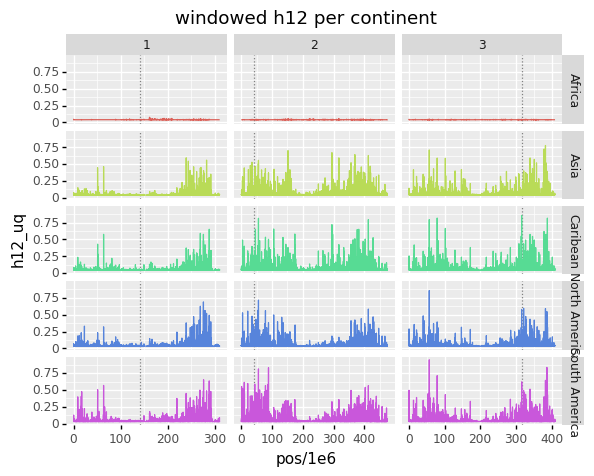

In [124]:
h12meantab = h12tabc.groupby(['group','chr','pos'])['h12'].quantile([0.25,0.5,0.75]).unstack()
h12meantab = h12meantab.reset_index().rename(columns={0.25:"h12_lq",
                                                      0.50:"h12_mean",
                                                      0.75:"h12_uq"})
p = ggplot(h12meantab,aes(x='pos/1e6',
                          ymin="h12_lq",ymax="h12_mean",y="h12_uq",
                          group="group",color="group")) + \
  geom_vline(aes(xintercept='pos/1e6'),
             data=haps,linetype="dotted",color="grey") +\
  geom_line() +\
  ggtitle("windowed h12 per continent") +\
  theme(legend_position='none') + facet_grid(("group","chr"),scales="free_x",space="free_x")

#geom_ribbon(aes(group="region")) + \
  
ggsave(plot=p, width=500,height=200,units='mm',filename='h12_{}bp_allchroms_allpops_meanh12_continent.png'.format(blen), dpi=400)


print(p)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_500bp_allchroms_allpops_meanh1_continent.png


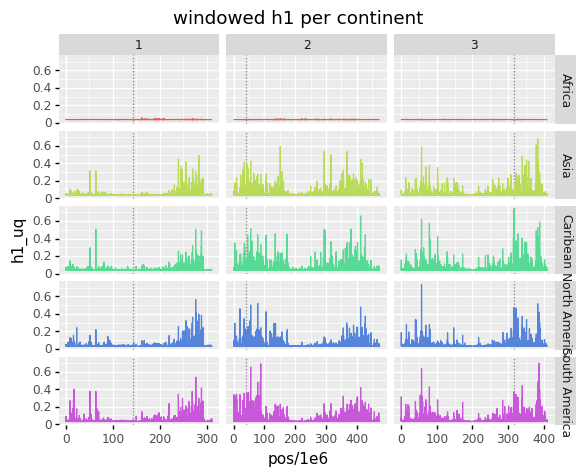

In [125]:
h1meantab = h12tabc.groupby(['group','chr','pos'])['h1'].quantile([0.25,0.5,0.75]).unstack()
h1meantab = h1meantab.reset_index().rename(columns={0.25:"h1_lq",
                                                      0.50:"h1_mean",
                                                      0.75:"h1_uq",
                                                     "contgroup":"region"})
p = ggplot(h1meantab,aes(x='pos/1e6',
                          ymin="h1_lq",ymax="h1_mean",y="h1_uq",
                          group="group",color="group")) + \
  geom_vline(aes(xintercept='pos/1e6'),
             data=haps,linetype="dotted",color="grey") +\
  geom_line() +\
  ggtitle("windowed h1 per continent") +\
  theme(legend_position='none') + facet_grid(("group","chr"),scales="free_x",space="free_x")

#geom_ribbon(aes(group="region")) + \
  
ggsave(plot=p, width=500,height=200,units='mm',filename='h12_{}bp_allchroms_allpops_meanh1_continent.png'.format(blen), dpi=400)


print(p)
